# Gauss-Newton inference for non-conjugate GPs

Gauss-Newton runs the **same Newton iteration** as Laplace but with a strictly-positive lower bound (a "PSD floor") on the diagonal site precision:

$$\Lambda_n = \max\!\left(-\frac{\partial^2 \log p(y_n \mid f_n)}{\partial f_n^2}, \, \tau\right)$$

where $\tau > 0$ is the floor. The two strategies differ **only** in that floor's default value — Laplace floors at $10^{-6}$, GN floors at $10^{-3}$. Everything else is identical.

**Why the floor matters.** For **log-concave** likelihoods (Bernoulli, Poisson) the negative Hessian is positive everywhere, so neither floor bites and **GN ≡ Laplace exactly**.

For **non-log-concave** likelihoods — StudentT, mixture-of-Gaussians, anything with heavy tails — the Hessian becomes *positive* in the tails:

$$\frac{\partial^2}{\partial f^2} \log p_{\text{StudentT}}(y \mid f, \nu, \sigma) = \frac{(\nu+1)((y-f)^2 - \nu \sigma^2)}{(\nu \sigma^2 + (y-f)^2)^2}$$

which is positive whenever $|y-f|^2 > \nu \sigma^2$ (residual "big enough that the heavy tail kicks in"). At those points $-h_n < 0$. Both Laplace and GN catch this with the floor; GN's larger floor is just a more conservative safety belt.

**What this notebook shows:** two regimes of GP-Laplace-style inference. In both, GN and Laplace converge to the same posterior — the floor difference is invisible at convergence. The honest answer to "when do you pick GN over Laplace?" is **almost never**; pick GN if you want the larger floor as a safety habit, otherwise stick with Laplace. The real cost in non-log-concave problems is the **damping** parameter, not the floor.

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from pyrox.gp import (
    RBF,
    BernoulliLikelihood,
    GaussNewtonInference,
    GPPrior,
    LaplaceInference,
    StudentTLikelihood,
)


plt.rcParams["figure.dpi"] = 110
key = jax.random.PRNGKey(0)

/home/azureuser/localfiles/pyrox/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Regime 1 — Bernoulli classification (log-concave)

Same setup as the Laplace notebook. We expect GN and Laplace to match: the Bernoulli Hessian $-\sigma(f)(1-\sigma(f))$ is always negative, so the floor $\tau$ never bites.

In [2]:
N = 60
X = jnp.linspace(-3.0, 3.0, N)[:, None]
f_true = 2.0 * jnp.sin(X[:, 0]) + 0.4 * X[:, 0]
probs_true = jax.nn.sigmoid(f_true)
y_bin = (jax.random.uniform(key, (N,)) < probs_true).astype(jnp.float32)

prior = GPPrior(kernel=RBF(init_lengthscale=0.6, init_variance=1.5), X=X)
lik = BernoulliLikelihood()

cond_lap = LaplaceInference(max_iter=50).fit(prior, lik, y_bin)
cond_gn = GaussNewtonInference(max_iter=50).fit(prior, lik, y_bin)

print(
    f"Laplace        iters={cond_lap.n_iter}  log_marg={float(cond_lap.log_marginal_approx):.4f}"
)
print(
    f"Gauss-Newton   iters={cond_gn.n_iter}  log_marg={float(cond_gn.log_marginal_approx):.4f}"
)
print(
    f"max |q_mean diff|: {float(jnp.max(jnp.abs(cond_lap.q_mean - cond_gn.q_mean))):.2e}"
)
print(
    f"max |q_var diff|:  {float(jnp.max(jnp.abs(cond_lap.q_var - cond_gn.q_var))):.2e}"
)

Laplace        iters=6  log_marg=-25.6915
Gauss-Newton   iters=6  log_marg=-25.6915
max |q_mean diff|: 0.00e+00
max |q_var diff|:  0.00e+00


Identical posteriors to ~ float32 noise. Diagnostic plot of the per-point site precisions confirms the regimes match.

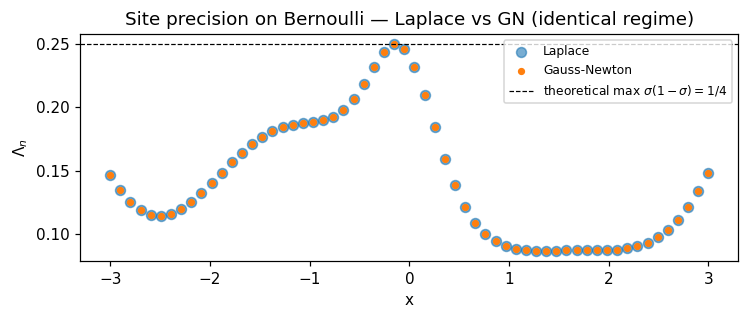

In [3]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.scatter(X[:, 0], np.asarray(cond_lap.site_nat2), s=42, label="Laplace", alpha=0.6)
ax.scatter(X[:, 0], np.asarray(cond_gn.site_nat2), s=14, label="Gauss-Newton")
ax.axhline(
    0.25, color="k", ls="--", lw=0.8, label=r"theoretical max $\sigma(1-\sigma)=1/4$"
)
ax.set_xlabel("x")
ax.set_ylabel(r"$\Lambda_n$")
ax.set_title("Site precision on Bernoulli — Laplace vs GN (identical regime)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Regime 2 — StudentT regression with outliers (non-log-concave)

Here the Hessian goes positive at points where the residual $|y-f|$ is large. Two outliers are planted in an otherwise-clean sinusoid.

In [4]:
key2, key3 = jax.random.split(jax.random.PRNGKey(42), 2)
N = 40
X = jnp.linspace(-3.0, 3.0, N)[:, None]
f_true = jnp.sin(X[:, 0])
y_clean = f_true + 0.1 * jax.random.normal(key2, (N,))
# Plant two outliers
outlier_idx = [12, 28]
y = y_clean.at[outlier_idx[0]].set(4.0).at[outlier_idx[1]].set(-4.0)

prior_t = GPPrior(kernel=RBF(init_lengthscale=0.7, init_variance=1.0), X=X)
lik_t = StudentTLikelihood(df=3.0, scale=0.3)

# Pure Newton oscillates on this non-log-concave likelihood; both strategies
# expose a ``damping`` argument that takes a convex combination of the
# previous iterate and the full Newton step. ``damping=0.3`` converges in
# ~50 iterations.
cond_lap = LaplaceInference(max_iter=200, damping=0.3).fit(prior_t, lik_t, y)
cond_gn = GaussNewtonInference(max_iter=200, damping=0.3).fit(prior_t, lik_t, y)

print(
    f"Laplace         iters={cond_lap.n_iter:3d}  conv={cond_lap.converged}  "
    f"log_marg={float(cond_lap.log_marginal_approx):.3f}"
)
print(
    f"Gauss-Newton    iters={cond_gn.n_iter:3d}  conv={cond_gn.converged}  "
    f"log_marg={float(cond_gn.log_marginal_approx):.3f}"
)

Laplace         iters= 35  conv=True  log_marg=-29.481
Gauss-Newton    iters= 35  conv=True  log_marg=-29.481


Inspect the *signed* per-point Hessian at convergence — values where $-h_n < 0$ are where Laplace would float its precision down to the floor and GN bumps it up to $\tau = 10^{-3}$. The outlier points are exactly where the two strategies differ.

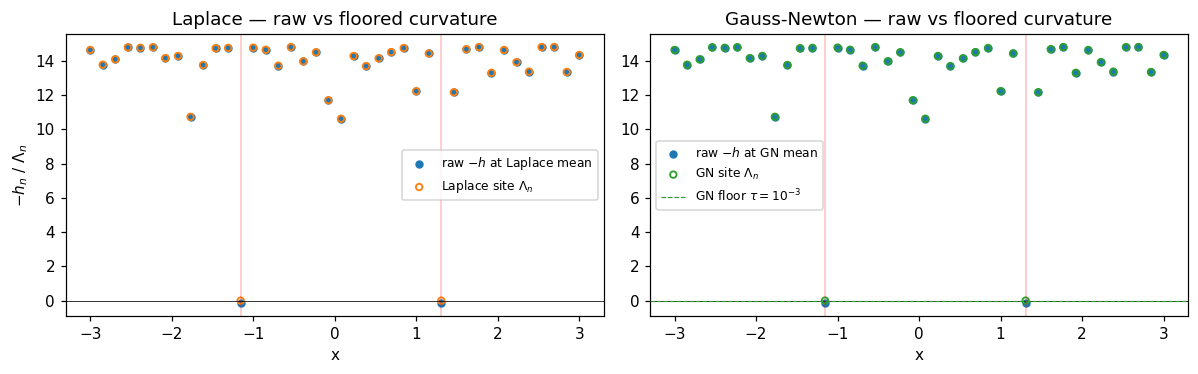

In [5]:
def neg_hess_at(f, y, lik):
    def per_n(f_n, y_n):
        return jax.grad(jax.grad(lambda fv: lik.log_prob(fv[None], y_n[None])))(f_n)

    return -jax.vmap(per_n)(f, y)


neg_h_lap = neg_hess_at(cond_lap.q_mean, y, lik_t)
neg_h_gn = neg_hess_at(cond_gn.q_mean, y, lik_t)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5), sharey=False)
ax = axes[0]
ax.scatter(
    X[:, 0], np.asarray(neg_h_lap), s=20, label=r"raw $-h$ at Laplace mean", color="C0"
)
ax.scatter(
    X[:, 0],
    np.asarray(cond_lap.site_nat2),
    s=18,
    label="Laplace site $\\Lambda_n$",
    facecolors="none",
    edgecolors="C1",
    lw=1.2,
)
ax.axhline(0, color="k", lw=0.5)
for i in outlier_idx:
    ax.axvline(X[i, 0], color="red", alpha=0.25, lw=1)
ax.set_title("Laplace — raw vs floored curvature")
ax.set_xlabel("x")
ax.set_ylabel(r"$-h_n$ / $\Lambda_n$")
ax.legend(fontsize=8)

ax = axes[1]
ax.scatter(
    X[:, 0], np.asarray(neg_h_gn), s=20, label=r"raw $-h$ at GN mean", color="C0"
)
ax.scatter(
    X[:, 0],
    np.asarray(cond_gn.site_nat2),
    s=18,
    label="GN site $\\Lambda_n$",
    facecolors="none",
    edgecolors="C2",
    lw=1.2,
)
ax.axhline(0, color="k", lw=0.5)
ax.axhline(1e-3, color="C2", ls="--", lw=0.8, label=r"GN floor $\tau=10^{-3}$")
for i in outlier_idx:
    ax.axvline(X[i, 0], color="red", alpha=0.25, lw=1)
ax.set_title("Gauss-Newton — raw vs floored curvature")
ax.set_xlabel("x")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

At the two outlier locations, the raw $-h$ goes negative — these points are in the heavy-tail regime, where the StudentT log-likelihood is *concave-up* (positive curvature), so Newton's exact-Hessian step would be ill-defined. Both strategies floor the precision at outliers; GN's larger default floor leaves a more obvious "step up" pattern.

## Predictive consequences

At convergence the two posteriors are essentially identical — the floor doesn't bite when both strategies have damped their way to the same fixed point.

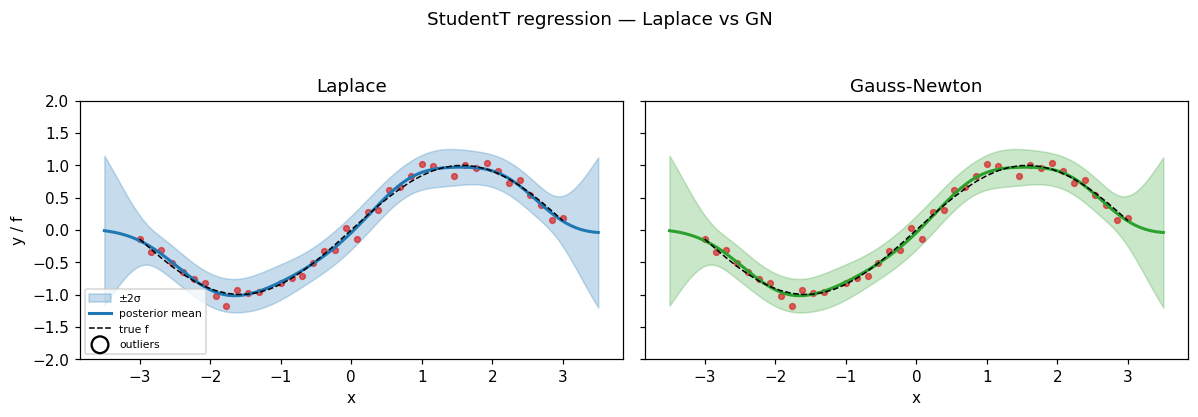

In [6]:
X_star = jnp.linspace(-3.5, 3.5, 200)[:, None]
m_lap, v_lap = cond_lap.predict(X_star)
m_gn, v_gn = cond_gn.predict(X_star)
m_lap, v_lap = np.asarray(m_lap), np.asarray(v_lap)
m_gn, v_gn = np.asarray(m_gn), np.asarray(v_gn)
sd_lap = np.sqrt(np.maximum(v_lap, 0))
sd_gn = np.sqrt(np.maximum(v_gn, 0))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
for ax, name, m, sd, color in [
    (axes[0], "Laplace", m_lap, sd_lap, "C0"),
    (axes[1], "Gauss-Newton", m_gn, sd_gn, "C2"),
]:
    ax.fill_between(
        X_star[:, 0], m - 2.0 * sd, m + 2.0 * sd, alpha=0.25, color=color, label="±2σ"
    )
    ax.plot(X_star[:, 0], m, color=color, lw=2, label="posterior mean")
    ax.plot(X[:, 0], jnp.sin(X[:, 0]), "k--", lw=1, label="true f")
    ax.scatter(X[:, 0], y, c="C3", s=14, alpha=0.7)
    ax.scatter(
        X[outlier_idx, 0],
        y[jnp.array(outlier_idx)],
        facecolors="none",
        edgecolors="black",
        s=120,
        lw=1.5,
        label="outliers",
    )
    ax.set_title(name)
    ax.set_xlabel("x")
    ax.set_ylim(-2.0, 2.0)
axes[0].set_ylabel("y / f")
axes[0].legend(fontsize=7, loc="lower left")
fig.suptitle("StudentT regression — Laplace vs GN", y=1.04)
plt.tight_layout()
plt.show()

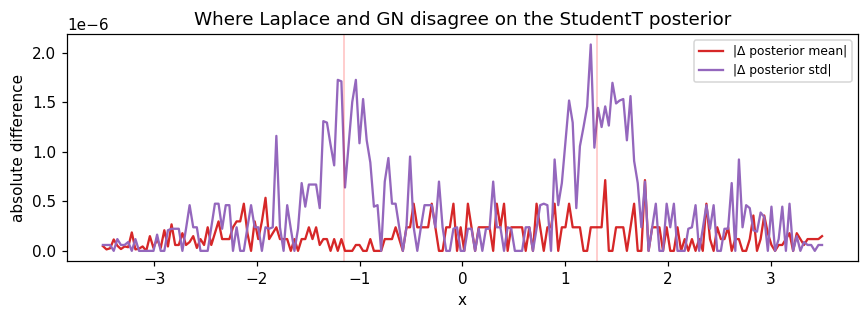

In [7]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(X_star[:, 0], np.abs(m_lap - m_gn), label="|Δ posterior mean|", color="C3")
ax.plot(X_star[:, 0], np.abs(sd_lap - sd_gn), label="|Δ posterior std|", color="C4")
for i in outlier_idx:
    ax.axvline(X[i, 0], color="red", alpha=0.25, lw=1)
ax.set_xlabel("x")
ax.set_ylabel("absolute difference")
ax.set_title("Where Laplace and GN disagree on the StudentT posterior")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Summary

- **Bernoulli (log-concave)**: GN ≡ Laplace to numerical precision. The floor is never reached.
- **StudentT (non-log-concave)**: the negative Hessian *does* go negative at outlier locations, but **both strategies catch it** — Laplace's $10^{-6}$ floor and GN's $10^{-3}$ floor both clip those points to a positive precision. The two strategies converge to the same posterior; the difference between the floors only affects intermediate iterates, not the fixed point.
- **The real lever for non-log-concave problems is `damping`**, not the floor. Pure Newton (`damping=1.0`) oscillates on StudentT-with-outliers; we set `damping=0.3` and both strategies converge in ~35 iterations.

**Practical guidance:**

- On log-concave likelihoods (Bernoulli, Poisson): use Laplace. GN gives the same answer at the same cost.
- On non-log-concave likelihoods (StudentT, mixture, etc.): use Laplace with `damping ∈ [0.3, 0.7]` as the first attempt; switch to GN only if you specifically prefer the more conservative floor for numerical safety. The two strategies will give virtually identical answers when both converge.
- The much bigger story in non-log-concave inference is moment matching (EP) and statistical linearization (PL) — they give different posteriors, not just different numerical paths. See those notebooks.

Both strategies share the same API:

```python
cond = prior.condition_nongauss(StudentTLikelihood(df=3, scale=0.3), y,
                                strategy=GaussNewtonInference(damping=0.3))
```